### Note 
An Experiment to compare our method with SOTA of TSF task. 
The initial code for this reproduction experiment is generated by claude sonnet 4.6 while being verified by the original author of this whole project.

In [1]:
import os
import math
import random
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset, DataLoader
from transformers import get_cosine_schedule_with_warmup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
DATA_PATH = '/kaggle/input/datasets/mohammadhossein77/ili-data/US_FLURATIO_Week.csv'
LOG_DIR   = '/kaggle/working/logs'
os.makedirs(LOG_DIR, exist_ok=True)

In [4]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
LOOKBACK           = 36
HORIZON            = 12
BATCH_SIZE         = 16    # no BERT memory constraint — larger batch is fine
ACCUMULATION_STEPS = 1     # effective batch = 32
EPOCHS             = 120
PATIENCE           = 10
WARMUP_EPOCHS      = 10
LR                 = 1e-4  # no BERT, single LR
SEED               = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Init

In [5]:
# PatchTST-specific
PATCH_LEN  = 4    
STRIDE     = 2
D_MODEL    = 128
N_HEADS    = 8     # head_dim = 128/8 = 16
NUM_LAYERS = 3
D_FF       = 256   # FF dim (paper uses 256 for shorter sequences)
DROPOUT    = 0.15

In [6]:
# =============================================================================
# 1. Data Loading & Preprocessing
#    Identical pipeline to DLinear / DSA baselines
# =============================================================================

df = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df.shape}')

# ── Numerical columns ─────────────────────────────────────────────────────────
numeric_df = df.iloc[:, :-4].copy()
numeric_df.drop(['date'], axis=1, inplace=True, errors='ignore')
numeric_df['start_date'] = pd.to_datetime(numeric_df['start_date'])
numeric_df['end_date']   = pd.to_datetime(numeric_df['end_date'])

# Cyclic week encoding
numeric_df['WEEK_sin'] = np.sin(2 * np.pi * (numeric_df['WEEK'] / 52))
numeric_df['WEEK_cos'] = np.cos(2 * np.pi * (numeric_df['WEEK'] / 52))
numeric_df.drop(['WEEK'], axis=1, inplace=True)

# Drop redundant columns
numeric_df.drop(['REGION TYPE', 'REGION', 'YEAR_WEEK'],
                axis=1, inplace=True, errors='ignore')
numeric_df.drop(['prior_history_std', 'prior_history_avg'],
                axis=1, inplace=True, errors='ignore')

numeric_df = numeric_df.replace('X', np.nan)

num_features = [
    'YEAR', 'WEEK_sin', 'WEEK_cos',
    '% WEIGHTED ILI',
    'AGE 0-4', 'AGE 5-24',
    'AGE 25-49', 'AGE 25-64', 'AGE 50-64', 'AGE 65',
    'ILITOTAL', 'NUM. OF PROVIDERS', 'TOTAL PATIENTS'
]
numeric_df[num_features] = numeric_df[num_features].apply(
    pd.to_numeric, errors='coerce')

merged_df = numeric_df.copy()
merged_df.sort_values('start_date', inplace=True)
print(f'Merged shape: {merged_df.shape}')

Raw shape: (1389, 25)
Merged shape: (1389, 16)


In [7]:
# ── Train / Val / Test split ──────────────────────────────────────────────────
n          = len(merged_df)
train_size = int(n * 0.8)
val_size   = int(n * 0.1)

train_df = merged_df.iloc[:train_size].copy()
val_df   = merged_df.iloc[train_size : train_size + val_size].copy()
test_df  = merged_df.iloc[train_size + val_size:].copy()
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')


Train: 1111 | Val: 138 | Test: 140


In [8]:
# ── Age imputation (same logic as DSA) ───────────────────────────────────────
for dff in [train_df, val_df, test_df]:
    mask_split = (dff['AGE 25-49'].isna() &
                  dff['AGE 50-64'].isna() &
                  ~dff['AGE 25-64'].isna())
    dff.loc[mask_split, 'AGE 25-49'] = dff.loc[mask_split, 'AGE 25-64'] * 0.6
    dff.loc[mask_split, 'AGE 50-64'] = dff.loc[mask_split, 'AGE 25-64'] * 0.4

    mask_comb = (~dff['AGE 25-49'].isna() &
                 ~dff['AGE 50-64'].isna() &
                 dff['AGE 25-64'].isna())
    dff.loc[mask_comb, 'AGE 25-64'] = (dff.loc[mask_comb, 'AGE 25-49'] +
                                        dff.loc[mask_comb, 'AGE 50-64'])

print('NaNs after imputation (train):')
print(train_df[num_features].isna().sum())

NaNs after imputation (train):
YEAR                 0
WEEK_sin             0
WEEK_cos             0
% WEIGHTED ILI       0
AGE 0-4              0
AGE 5-24             0
AGE 25-49            0
AGE 25-64            0
AGE 50-64            0
AGE 65               0
ILITOTAL             0
NUM. OF PROVIDERS    0
TOTAL PATIENTS       0
dtype: int64


In [9]:
# ── Scaling ───────────────────────────────────────────────────────────────────
feature_scaler = MinMaxScaler()
train_df[num_features] = feature_scaler.fit_transform(train_df[num_features])
val_df[num_features]   = feature_scaler.transform(val_df[num_features])
test_df[num_features]  = feature_scaler.transform(test_df[num_features])
joblib.dump(feature_scaler,
            os.path.join(LOG_DIR, 'patchtst_feature_scaler.pkl'))

target_scaler = MinMaxScaler()
train_df['OT'] = target_scaler.fit_transform(
    train_df['OT'].values.reshape(-1, 1)).flatten()
val_df['OT']   = target_scaler.transform(
    val_df['OT'].values.reshape(-1, 1)).flatten()
test_df['OT']  = target_scaler.transform(
    test_df['OT'].values.reshape(-1, 1)).flatten()
joblib.dump(target_scaler,
            os.path.join(LOG_DIR, 'patchtst_target_scaler.pkl'))

if 'OT' not in num_features:
    num_features.append('OT')
print(f'Total numerical features (incl. OT): {len(num_features)}')  # 14


Total numerical features (incl. OT): 14


In [10]:
# ── Sequence creation ─────────────────────────────────────────────────────────
def create_sequences(df, lookback, horizon):
    df = df.sort_values('start_date').reset_index(drop=True)
    X, y = [], []
    for i in range(len(df) - lookback - horizon + 1):
        X.append(df[num_features].iloc[i : i + lookback].values)   # (36, 14)
        y.append(df['OT'].iloc[i + lookback : i + lookback + horizon].values)
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32))


# Prepend tail for cold-start fix (same as DSA)
val_df_full  = pd.concat([train_df.iloc[-LOOKBACK:], val_df],  ignore_index=True)
test_df_full = pd.concat([val_df.iloc[-LOOKBACK:],  test_df],  ignore_index=True)

X_train, y_train = create_sequences(train_df,     LOOKBACK, HORIZON)
X_val,   y_val   = create_sequences(val_df_full,  LOOKBACK, HORIZON)
X_test,  y_test  = create_sequences(test_df_full, LOOKBACK, HORIZON)

print(f'Train : {X_train.shape} -> {y_train.shape}')
print(f'Val   : {X_val.shape}   -> {y_val.shape}')
print(f'Test  : {X_test.shape}  -> {y_test.shape}')


Train : (1064, 36, 14) -> (1064, 12)
Val   : (127, 36, 14)   -> (127, 12)
Test  : (129, 36, 14)  -> (129, 12)


In [11]:
# =============================================================================
# 2. Dataset & DataLoader
# =============================================================================

class NumericalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(NumericalDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(NumericalDataset(X_val,   y_val),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(NumericalDataset(X_test,  y_test),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches — Train: {len(train_loader)} | '
      f'Val: {len(val_loader)} | Test: {len(test_loader)}')



Batches — Train: 67 | Val: 8 | Test: 9


# PatchTST

In [12]:
# =============================================================================
# 3. PatchTST Model
#    Channel-Independent (CI) formulation — Nie et al., ICLR 2023
#    Each of the C channels is patched and processed independently.
#    Only the OT channel's prediction is returned (last column).
# =============================================================================

class PatchTST(nn.Module):
    def __init__(self,
                 seq_len      = 36,
                 horizon      = 12,
                 num_channels = 14,
                 patch_len    = 12,
                 stride       = 6,
                 d_model      = 128,
                 n_heads      = 8,
                 num_layers   = 3,
                 d_ff         = 256,
                 dropout      = 0.15):
        super().__init__()

        # Number of patches: (seq_len - patch_len) // stride + 1
        # For seq_len=36, patch_len=12, stride=6 → num_patches = 5
        assert (seq_len - patch_len) % stride == 0 or True, \
            "seq_len, patch_len, stride combination does not produce whole patches"
        self.num_patches  = (seq_len - patch_len) // stride + 1
        self.patch_len    = patch_len
        self.stride       = stride
        self.d_model      = d_model
        self.num_channels = num_channels
        self.ot_idx       = num_channels - 1  # OT is last column

        # ── Patch embedding: linear projection of each patch ──────────────────
        self.patch_proj = nn.Linear(patch_len, d_model)

        # ── Learnable positional encoding (one per patch position) ────────────
        self.pos_emb = nn.Parameter(
            torch.zeros(1, self.num_patches, d_model))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)

        # ── Transformer encoder (Pre-LN, as in the original PatchTST paper) ──
        encoder_layer = nn.TransformerEncoderLayer(
            d_model        = d_model,
            nhead          = n_heads,
            dim_feedforward = d_ff,
            dropout        = dropout,
            batch_first    = True,
            norm_first     = True,   # Pre-LN — PatchTST default
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(d_model)

        # ── Prediction head: flatten patches → forecast ───────────────────────
        # Input dim: num_patches * d_model = 5 * 128 = 640
        self.head = nn.Sequential(
            nn.Flatten(),                                         # (B*C, num_patches*d_model)
            nn.Linear(self.num_patches * d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, horizon),
        )

    def forward(self, x):                    # x: (B, T, C)
        B, T, C = x.shape

        # ── 1. Transpose → (B, C, T) for channel-independent patching ─────────
        x = x.transpose(1, 2)               # (B, C, T)

        # ── 2. Unfold into patches: (B, C, num_patches, patch_len) ────────────
        x = x.unfold(dimension=2,
                     size=self.patch_len,
                     step=self.stride)       # (B, C, num_patches, patch_len)

        # ── 3. Merge batch and channel dims for joint Transformer processing ──
        x = x.reshape(B * C,
                       self.num_patches,
                       self.patch_len)       # (B*C, num_patches, patch_len)

        # ── 4. Patch embedding + positional encoding ──────────────────────────
        x = self.patch_proj(x)              # (B*C, num_patches, d_model)
        x = x + self.pos_emb               # broadcast: (1, num_patches, d_model)

        # ── 5. Transformer ────────────────────────────────────────────────────
        x = self.transformer(x)            # (B*C, num_patches, d_model)
        x = self.norm(x)                   # (B*C, num_patches, d_model)

        # ── 6. Prediction head ────────────────────────────────────────────────
        x = self.head(x)                   # (B*C, horizon)

        # ── 7. Reshape and return OT channel only ─────────────────────────────
        x = x.reshape(B, C, -1)            # (B, C, horizon)
        return x[:, self.ot_idx, :]        # (B, horizon)


In [13]:
model = PatchTST(
    seq_len      = LOOKBACK,
    horizon      = HORIZON,
    num_channels = len(num_features),   # 14
    patch_len    = PATCH_LEN,
    stride       = STRIDE,
    d_model      = D_MODEL,
    n_heads      = N_HEADS,
    num_layers   = NUM_LAYERS,
    d_ff         = D_FF,
    dropout      = DROPOUT,
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / Total: {total:,}')
print(f'Num patches: {model.num_patches}')   # should print 5

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

updates_per_epoch = math.ceil(len(train_loader) / ACCUMULATION_STEPS)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = WARMUP_EPOCHS * updates_per_epoch,
    num_training_steps = EPOCHS       * updates_per_epoch,
)

criterion = nn.MSELoss()


/tmp/ipykernel_58/1385321554.py:50: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Trainable params: 680,716 / Total: 680,716
Num patches: 17


# Training

In [14]:
history         = {'epoch': [], 'train_loss': [], 'val_loss': []}
best_val_loss   = float('inf')
best_model_path = os.path.join(LOG_DIR, 'patchtst_best.pth')
p_counter       = 0

for epoch in tqdm(range(EPOCHS)):

    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    optimizer.zero_grad()
    epoch_train_loss = 0.0

    for batch_idx, (X_b, y_b) in enumerate(train_loader):
        X_b = X_b.to(device)
        y_b = y_b.to(device)

        preds = model(X_b)
        loss  = criterion(preds, y_b) / ACCUMULATION_STEPS
        loss.backward()

        if ((batch_idx + 1) % ACCUMULATION_STEPS == 0 or
                (batch_idx + 1) == len(train_loader)):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        epoch_train_loss += loss.item() * ACCUMULATION_STEPS

    avg_train = epoch_train_loss / len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b  = X_b.to(device)
            y_b  = y_b.to(device)
            preds     = model(X_b)
            val_loss += criterion(preds, y_b).item()

    avg_val = val_loss / len(val_loader)

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        p_counter     = 0
        torch.save(model.state_dict(), best_model_path)
        print(f'  ↓ New best at epoch {epoch} | val={avg_val:.6f}')
    else:
        if epoch >= WARMUP_EPOCHS:
            p_counter += 1
            if p_counter >= PATIENCE:
                print(f'Early stopping at epoch {epoch}')
                break

    if epoch % 10 == 0 or epoch < 5:
        print(f'Epoch {epoch:3d} | Train: {avg_train:.6f} | Val: {avg_val:.6f}')

print(f'\nBest val loss : {best_val_loss:.6f}')
print(f'Checkpoint    : {best_model_path}')

  1%|          | 1/120 [00:01<03:13,  1.62s/it]

  ↓ New best at epoch 0 | val=0.047204
Epoch   0 | Train: 0.085805 | Val: 0.047204


  2%|▏         | 2/120 [00:02<02:14,  1.14s/it]

  ↓ New best at epoch 1 | val=0.045678
Epoch   1 | Train: 0.030703 | Val: 0.045678


  2%|▎         | 3/120 [00:03<01:55,  1.01it/s]

...

  ↓ New best at epoch 16 | val=0.022817


 18%|█▊        | 21/120 [00:17<01:19,  1.25it/s]

Epoch  20 | Train: 0.010732 | Val: 0.025413


 22%|██▏       | 26/120 [00:22<01:21,  1.16it/s]

Early stopping at epoch 26

Best val loss : 0.022817
Checkpoint    : /kaggle/working/logs/patchtst_best.pth


# Performance Monitoring

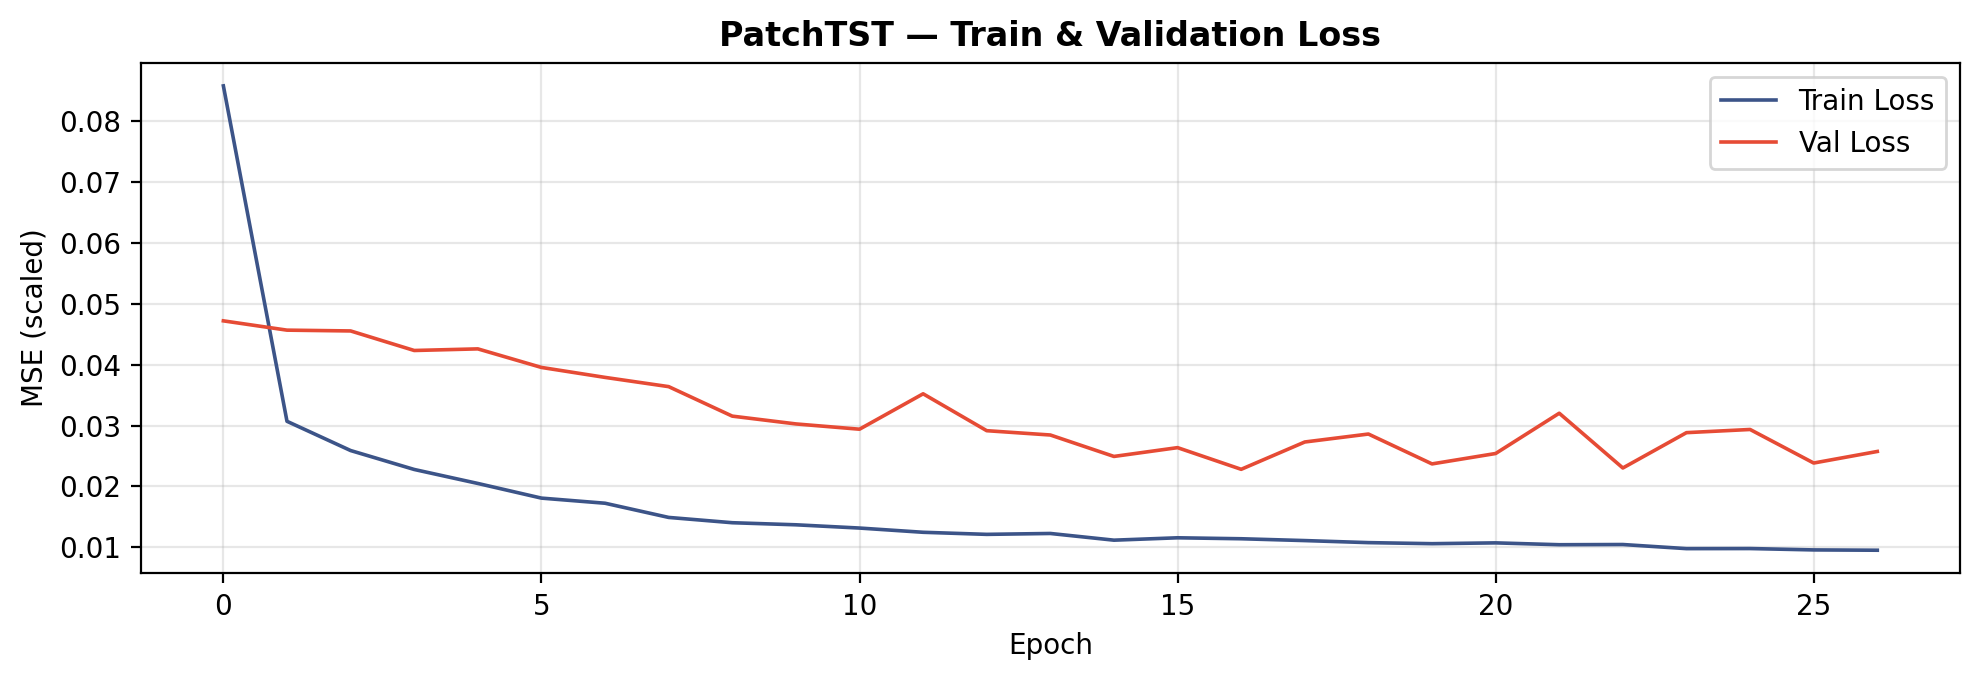

In [15]:
mpl.rcParams.update({'font.family': 'DejaVu Sans', 'axes.facecolor': 'white',
                     'figure.facecolor': 'white'})
plt.figure(figsize=(10, 3.5), dpi=200)
plt.plot(history['epoch'], history['train_loss'],
         color='#3C5488', label='Train Loss', linewidth=1.3)
plt.plot(history['epoch'], history['val_loss'],
         color='#E64B35', label='Val Loss',   linewidth=1.3)
plt.xlabel('Epoch'); plt.ylabel('MSE (scaled)')
plt.title('PatchTST — Train & Validation Loss', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{LOG_DIR}/patchtst_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b   = X_b.to(device)
        preds = model(X_b)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(y_b.numpy())

test_preds   = np.array(test_preds)    # (N, 12)
test_targets = np.array(test_targets)  # (N, 12)

# Inverse transform
inv_preds   = target_scaler.inverse_transform(
    test_preds.reshape(-1, 1)).reshape(-1, HORIZON)
inv_targets = target_scaler.inverse_transform(
    test_targets.reshape(-1, 1)).reshape(-1, HORIZON)

# Aggregate metrics
mse_val  = mean_squared_error(inv_targets.flatten(), inv_preds.flatten())
mae_val  = mean_absolute_error(inv_targets.flatten(), inv_preds.flatten())
rmse_val = np.sqrt(mse_val)

print('=' * 60)
print(f'  PatchTST (unimodal) | Test MSE : {mse_val:.4f}')
print(f'                      | Test MAE : {mae_val:.4f}')
print(f'                      | Test RMSE: {rmse_val:.4f}  (inverse-scaled)')
print(f'  DLinear (unimodal)  | Test MSE : 1.6642')
print(f'  DSA (mean / best)   | Test MSE : 1.120 ± 0.096 / 0.9749')
print('=' * 60)


  PatchTST (unimodal) | Test MSE : 1.3181
                      | Test MAE : 0.8026
                      | Test RMSE: 1.1481  (inverse-scaled)
  DLinear (unimodal)  | Test MSE : 1.6642
  DSA (mean / best)   | Test MSE : 1.120 ± 0.096 / 0.9749


In [17]:
# ── Per-sample & per-horizon errors (for DM test) ─────────────────────────────
per_sample_mse  = ((inv_preds - inv_targets) ** 2).mean(axis=1)   # (N,)
per_horizon_mse = ((inv_preds - inv_targets) ** 2).mean(axis=0)   # (12,)

np.save(f'{LOG_DIR}/errors_patchtst.npy',  per_sample_mse)
np.save(f'{LOG_DIR}/horizon_patchtst.npy', per_horizon_mse)
np.save(f'{LOG_DIR}/preds_patchtst.npy',   inv_preds)
np.save(f'{LOG_DIR}/targets_patchtst.npy', inv_targets)

print('\nPer-horizon MSE (weeks 1–12):')
for h, hmse in enumerate(per_horizon_mse, 1):
    print(f'  Week {h:2d}: {hmse:.4f}')


Per-horizon MSE (weeks 1–12):
  Week  1: 0.5559
  Week  2: 0.6201
  Week  3: 0.7979
  Week  4: 1.1129
  Week  5: 1.2780
  Week  6: 1.4207
  Week  7: 1.5342
  Week  8: 1.6545
  Week  9: 1.6761
  Week 10: 1.7369
  Week 11: 1.6957
  Week 12: 1.7343


# Viz

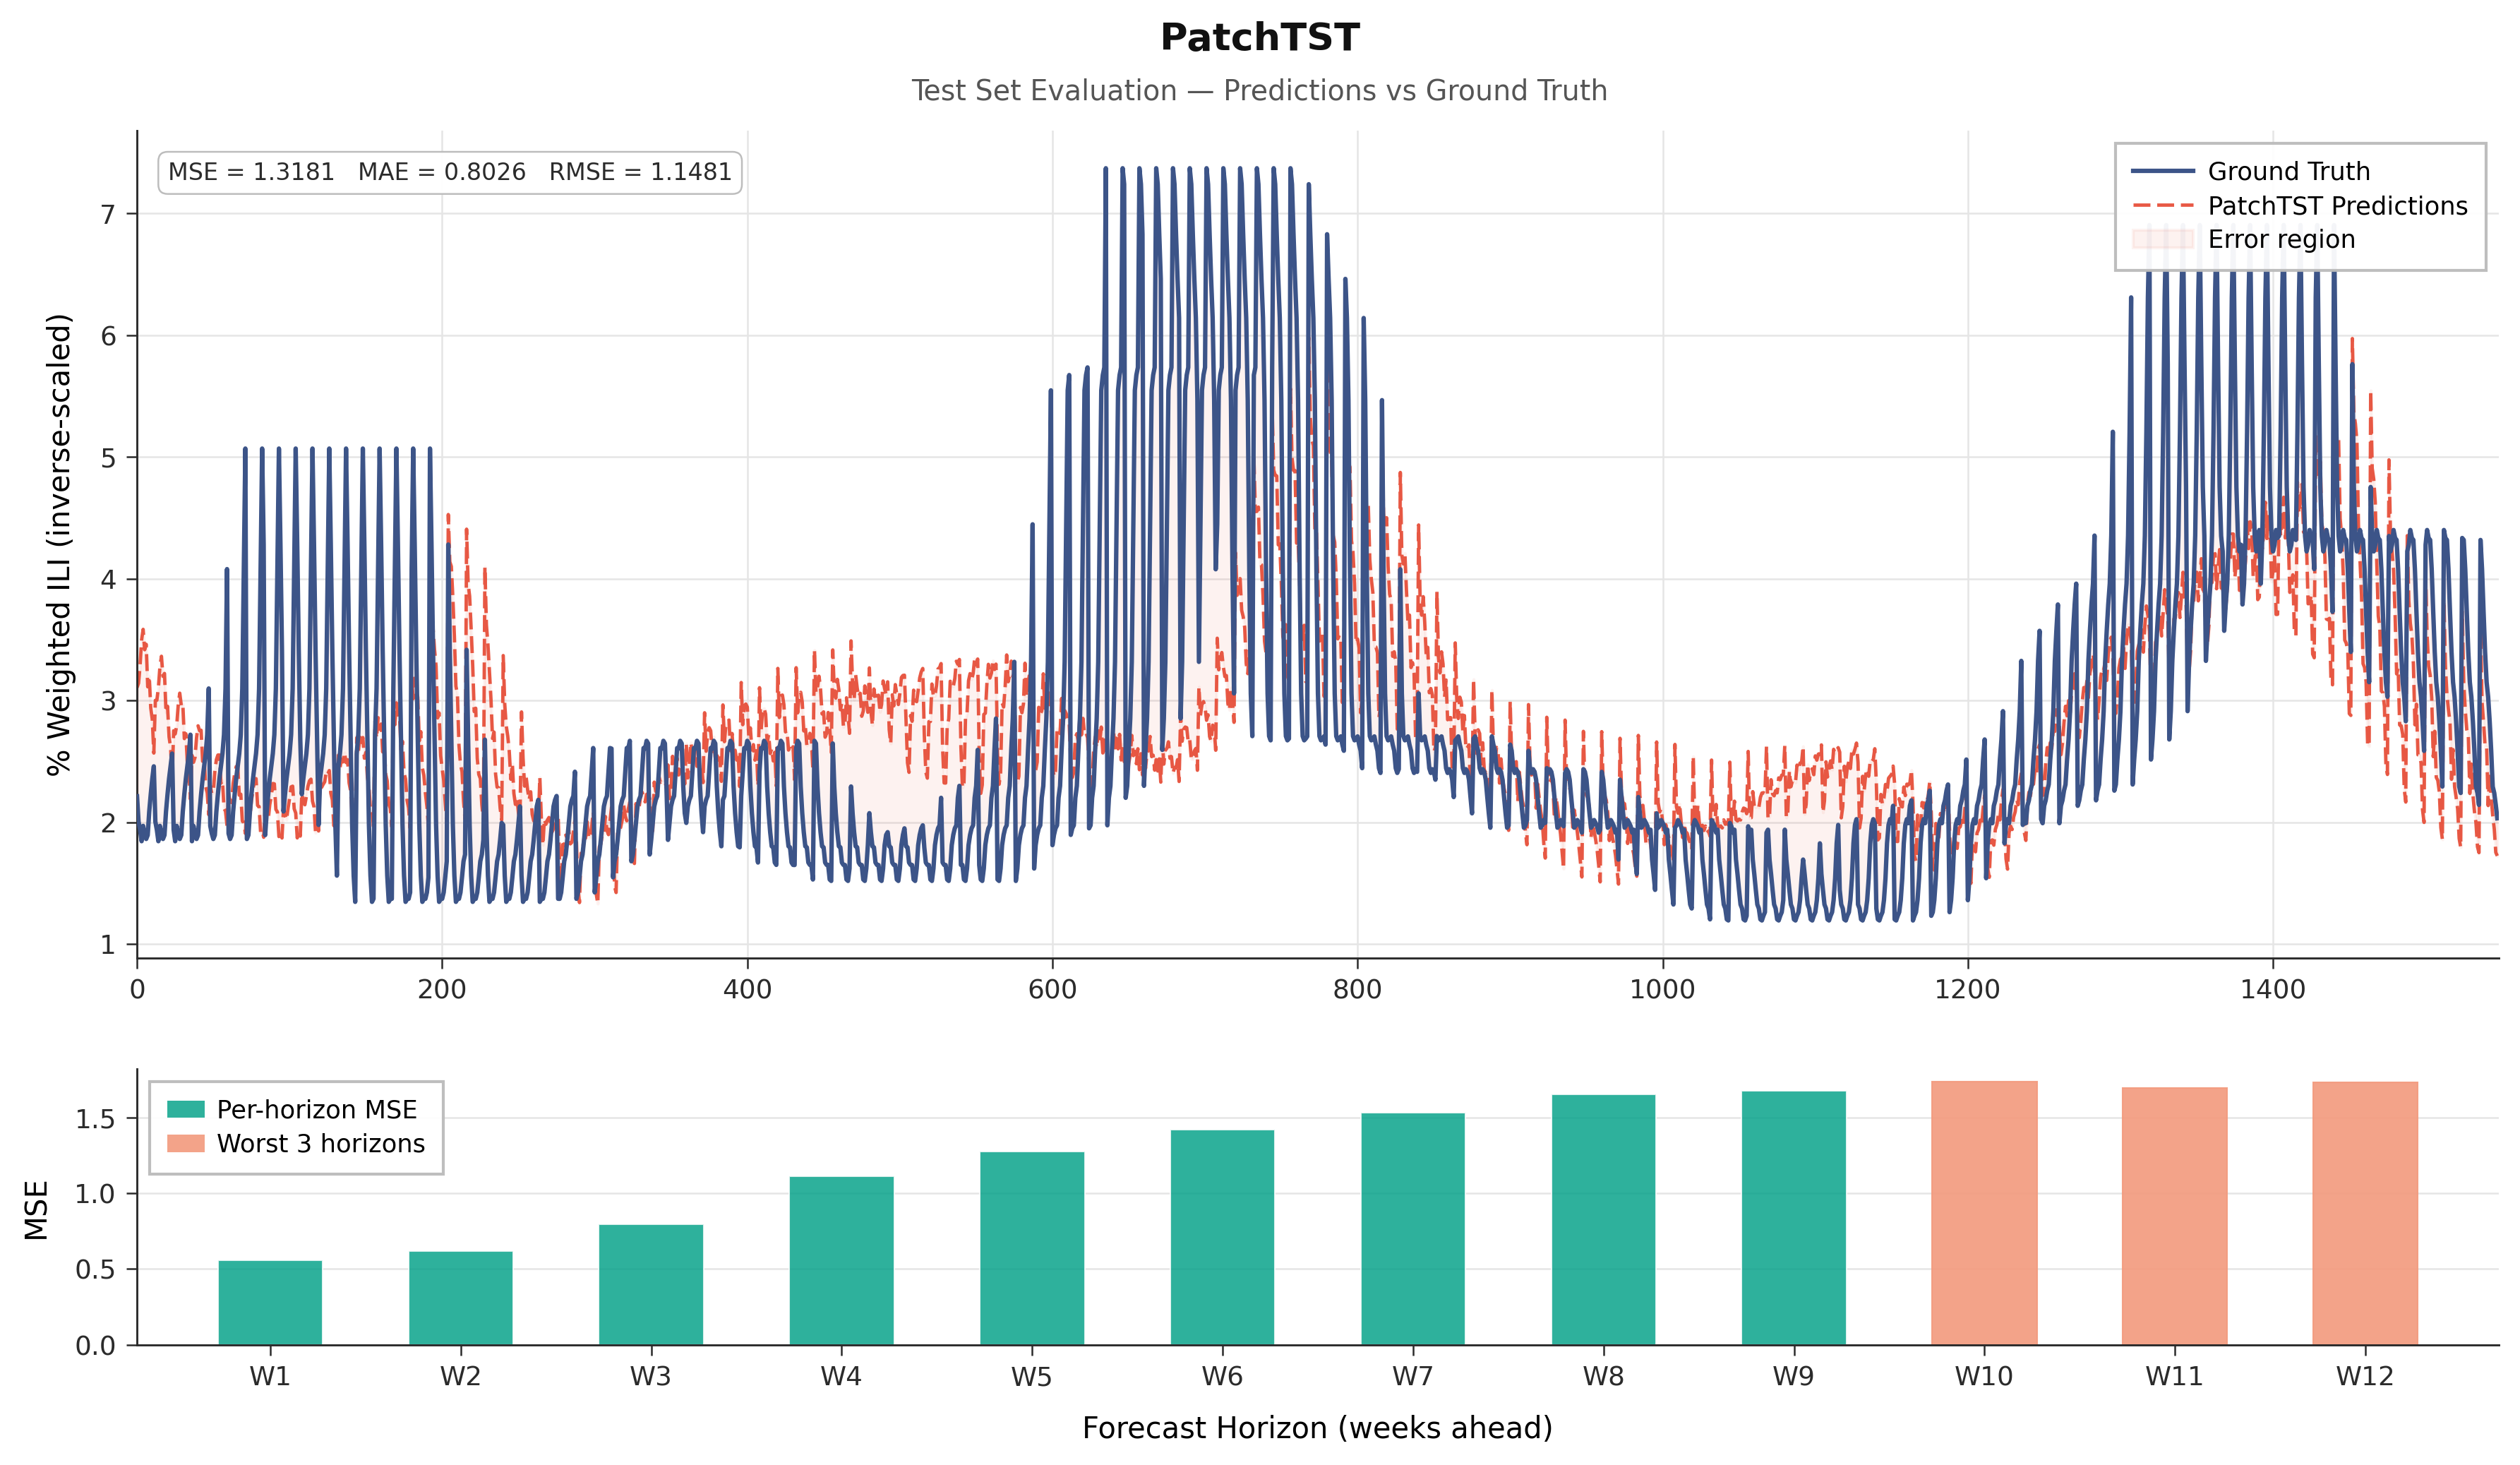

Done. All outputs saved to /kaggle/working/logs


In [18]:
C_TRUTH  = '#3C5488'
C_PRED   = '#E64B35'
C_FILL   = '#E64B35'
C_BAR    = '#00A087'
C_WORST  = '#F39B7F'
C_GRID   = '#E5E5E5'

mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.linewidth': 0.7,  'axes.edgecolor': '#2B2B2B',
    'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'xtick.major.size': 3.5,  'ytick.major.size': 3.5,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'xtick.color': '#2B2B2B', 'ytick.color': '#2B2B2B',
    'legend.framealpha': 0.95, 'legend.edgecolor': '#BBBBBB',
    'legend.fancybox': False,
})

flat_targets = inv_targets.flatten()
flat_preds   = inv_preds.flatten()
timesteps    = np.arange(len(flat_targets))

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 6.5), dpi=300,
    gridspec_kw={'height_ratios': [3, 1]}
)
fig.text(0.5, 1.03, 'PatchTST',
         ha='center', va='bottom',
         fontsize=13, fontweight='bold', color='#111111')
fig.text(0.5, 0.995, 'Test Set Evaluation — Predictions vs Ground Truth',
         ha='center', va='bottom',
         fontsize=9.5, fontweight='normal', color='#555555')

ax1.plot(timesteps, flat_targets,
         color=C_TRUTH, linewidth=1.5, alpha=1.0, label='Ground Truth', zorder=3)
ax1.plot(timesteps, flat_preds,
         color=C_PRED, linewidth=1.15, linestyle='--', dashes=(5, 2),
         alpha=0.92, label='PatchTST Predictions', zorder=2)
ax1.fill_between(timesteps, flat_targets, flat_preds,
                 color=C_FILL, alpha=0.07, zorder=1, label='Error region')
ax1.set_ylabel('% Weighted ILI (inverse-scaled)', fontsize=10, labelpad=8)
ax1.set_xlim(0, len(flat_targets))
ax1.grid(True, color=C_GRID, linewidth=0.6)
ax1.set_axisbelow(True)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='both', labelsize=9)
ax1.legend(loc='upper right', fontsize=8.5, handlelength=2.4,
           handletextpad=0.6, borderpad=0.7, labelspacing=0.4)
ax1.text(0.013, 0.963,
         f'MSE = {mse_val:.4f}   MAE = {mae_val:.4f}   RMSE = {rmse_val:.4f}',
         transform=ax1.transAxes, fontsize=8,
         verticalalignment='top', color='#2B2B2B',
         bbox=dict(boxstyle='round,pad=0.40', facecolor='white',
                   edgecolor='#BBBBBB', linewidth=0.6, alpha=0.97))

horizon_steps = np.arange(1, 13)
bars = ax2.bar(horizon_steps, per_horizon_mse,
               color=C_BAR, alpha=0.82, width=0.55,
               edgecolor='white', linewidth=0.5, zorder=2)
top3_idx = np.argsort(per_horizon_mse)[-3:]
for idx in top3_idx:
    bars[idx].set_color(C_WORST)
    bars[idx].set_alpha(0.92)

ax2.set_xlabel('Forecast Horizon (weeks ahead)', fontsize=10, labelpad=8)
ax2.set_ylabel('MSE', fontsize=10, labelpad=8)
ax2.set_xticks(horizon_steps)
ax2.set_xticklabels([f'W{h}' for h in horizon_steps], fontsize=8.5)
ax2.grid(axis='y', color=C_GRID, linewidth=0.6)
ax2.set_axisbelow(True)
ax2.set_xlim(0.3, 12.7)
ax2.tick_params(axis='both', labelsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(handles=[
    Patch(facecolor=C_BAR,   alpha=0.82, label='Per-horizon MSE'),
    Patch(facecolor=C_WORST, alpha=0.92, label='Worst 3 horizons'),
], fontsize=8.5, loc='upper left', handlelength=1.5,
   handletextpad=0.5, borderpad=0.7, labelspacing=0.4)

plt.tight_layout(h_pad=2.2)
plt.savefig(f'{LOG_DIR}/patchtst_test_evaluation.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Done. All outputs saved to', LOG_DIR)


In [19]:
# !rm -rf /kaggle/working/*